In [14]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR 
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.model_selection import RandomizedSearchCV 
import warnings

In [2]:
df=pd.read_csv(r"D:\Ml_Project2\notebook\stud.csv")

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
X=df.drop(columns=['math score'],axis=1)

In [5]:
y=df['math score']

In [9]:
num_feature=X.select_dtypes(exclude='object').columns 
cat_feature=X.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

cal_transform=OneHotEncoder()
num_transform=StandardScaler()

preprocessor=ColumnTransformer(
    [
        ("OneHotEncoder",cal_transform,cat_feature),
        ("StandardScaler",num_transform,num_feature),
    ]
)

In [10]:
X=preprocessor.fit_transform(X)

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [32]:
def evalute_model(true,prediccted):
    mae=mean_absolute_error(true,prediccted)
    mse=mean_squared_error(true,prediccted)
    rmse=np.sqrt(mean_squared_error(true,prediccted))
    r2_scores=r2_score(true,prediccted)

    return mae,rmse,r2_scores

In [34]:
models={
    "Linear Regression":LinearRegression(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "KNeighbors Regression":KNeighborsRegressor(),
    "Decision Tree":DecisionTreeRegressor(),
    "RandomForest Regressor":RandomForestRegressor(),
    "AdaBoostRegressor": AdaBoostRegressor()

}
model_list=[]
r2_list=[]

for  i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)

    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    model_train_mae,model_train_rmse,model_train_r2=evalute_model(y_train,y_train_pred)
    model_test_mae,model_test_rmse,model_test_r2=evalute_model(y_test,y_test_pred)


    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])


    print("Model performance for train set")
    print("-Root mean squared Error:{:.4f}".format(model_train_rmse))
    print("-Mean absolute Error:{:.4f}".format(model_train_mae))
    print("-R2 score:{:.4f}".format(model_train_r2))

    print('--------------------------------')
    print("Model performance for test set")
    print("-Root mean squared Error:{:.4f}".format(model_test_rmse))
    print("-Mean absolute Error:{:.4f}".format(model_test_mae))
    print("-R2 score:{:.4f}".format(model_test_r2))

    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')


Linear Regression
Model performance for train set
-Root mean squared Error:5.3333
-Mean absolute Error:4.2774
-R2 score:0.8738
--------------------------------
Model performance for test set
-Root mean squared Error:5.3936
-Mean absolute Error:4.2035
-R2 score:0.8804


Lasso
Model performance for train set
-Root mean squared Error:6.5938
-Mean absolute Error:5.2063
-R2 score:0.8071
--------------------------------
Model performance for test set
-Root mean squared Error:6.5197
-Mean absolute Error:5.1579
-R2 score:0.8253


Ridge
Model performance for train set
-Root mean squared Error:5.3233
-Mean absolute Error:4.2650
-R2 score:0.8743
--------------------------------
Model performance for test set
-Root mean squared Error:5.3904
-Mean absolute Error:4.2111
-R2 score:0.8806




KNeighbors Regression
Model performance for train set
-Root mean squared Error:5.7015
-Mean absolute Error:4.5072
-R2 score:0.8558
--------------------------------
Model performance for test set
-Root mean squared Error:7.2520
-Mean absolute Error:5.6360
-R2 score:0.7839


Decision Tree
Model performance for train set
-Root mean squared Error:0.2795
-Mean absolute Error:0.0187
-R2 score:0.9997
--------------------------------
Model performance for test set
-Root mean squared Error:7.9047
-Mean absolute Error:6.1550
-R2 score:0.7432


RandomForest Regressor
Model performance for train set
-Root mean squared Error:2.2513
-Mean absolute Error:1.8041
-R2 score:0.9775
--------------------------------
Model performance for test set
-Root mean squared Error:5.9617
-Mean absolute Error:4.5801
-R2 score:0.8539


AdaBoostRegressor
Model performance for train set
-Root mean squared Error:5.8071
-Mean absolute Error:4.7612
-R2 score:0.8504
--------------------------------
Model performance for tes

In [35]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model Name','R2_score']).sort_values(by=['R2_score'],ascending=False)

,Model Name,R2_score
2,Ridge,0.880593
0,Linear Regression,0.880449
5,RandomForest Regressor,0.853941
6,AdaBoostRegressor,0.849648
1,Lasso,0.825320
3,KNeighbors Regression,0.783876
4,Decision Tree,0.743218


In [36]:
lin_model=LinearRegression(fit_intercept=True)
lin_model=lin_model.fit(X_train,y_train)
y_pred=lin_model.predict(X_test)
score=r2_score(y_test,y_pred)*100
print("Accuracy of the model is %.2f"%score)

Accuracy of the model is 88.04


Text(0, 0.5, 'Pedicted')

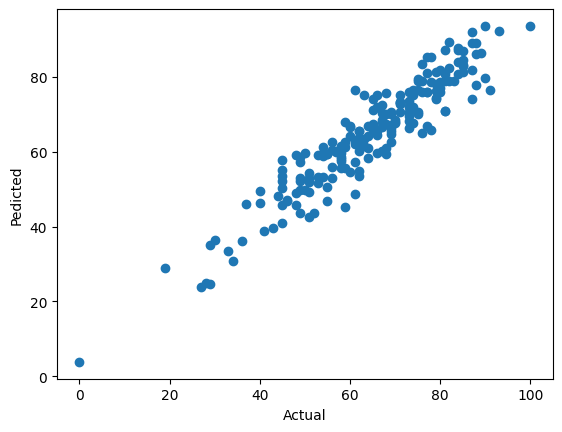

In [37]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Pedicted')

<AxesSubplot:xlabel='math score'>

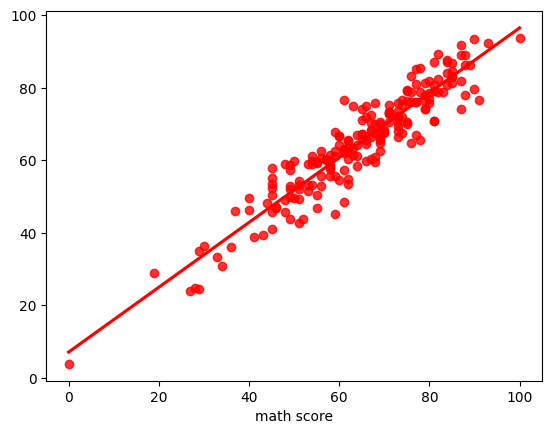

In [38]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='red')